# Setup

In [1]:
# Заставляем ноутбук обновлять импорты автоматически
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

from hydra.utils import instantiate
from omegaconf import OmegaConf


# 1. Вычисляем корень проекта ОДИН РАЗ
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 2. Инициализируем Hydra и резолверы
from src.utils.notebook_setup import setup_notebook #noqa E402


cfg = setup_notebook()
from src.utils.logger import setup_logging #noqa E402


setup_logging()

# 3. Трюк: принудительно подменяем переменную paths, если она не разрешилась
if "paths" not in cfg:
    cfg.paths = OmegaConf.create()
cfg.paths.data_dir = str(PROJECT_ROOT / "data")

# 4. Инициализируем токенизатор
tokenizer = instantiate(cfg.model.tokenizer).build()
print(f"Environment ready. Root: {PROJECT_ROOT}")
# У генеративных HF моделей параметр обычно называется name_or_path или model_name_or_path
print(f"Model: {cfg.model.model_name}")

INFO:src.utils.notebook_setup:NLP Environment ready. Root: c:\machine_translate_rus_abkhaz
c:\machine_translate_rus_abkhaz\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-07-27 04:42:27] INFO [src.core.models.tokenization:46] Загрузка токенизатора: HuggingFaceM4/tiny-random-LlamaForCausalLM


[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got -1. This may result in unexpected behavior.


Environment ready. Root: c:\machine_translate_rus_abkhaz
Model: HuggingFaceM4/tiny-random-LlamaForCausalLM


# Data Loading

In [2]:
from src.core.data.builder import NLPDataModule


# Инициализируем универсальный DataModule
datamodule = NLPDataModule(data_cfg=cfg.data, tokenizer=tokenizer)

# Запускаем загрузку и применение трансформаций
datamodule.prepare_data()

# Загружаем обработанный датасет в память (stage="fit")
datamodule.setup(stage="fit")

dataset = datamodule.train_dataset
print(f"Dataset schema: {dataset.column_names}")
print(f"Train size: {len(dataset)} examples")

[2026-07-27 04:42:40] INFO [src.core.data.builder:86] Начинаем загрузку и применение трансформаций...
[2026-07-27 04:42:40] INFO [src.core.data.fetcher:121] Загрузка локального файла: c:\machine_translate_rus_abkhaz\data\raw\ab-mono.txt (loader=text)
[2026-07-27 04:42:46] INFO [src.core.data.transforms:332] Применение пайплайна очистки текста...
[2026-07-27 04:42:48] INFO [src.core.data.transforms:233] Применение валидации записей (Pydantic)...
[2026-07-27 04:42:51] INFO [src.core.data.transforms:273] Валидация завершена: 2639863 -> 2639863 записей
[2026-07-27 04:42:51] INFO [src.core.data.transforms:76] Применение токенизации...
[2026-07-27 04:42:53] INFO [src.core.data.transforms:170] Упаковка последовательностей (Sequence Packing)...
[2026-07-27 04:42:53] INFO [src.core.data.transforms:332] Применение пайплайна очистки текста...


Cleaning text (num_proc=4): 100%|██████████| 329983/329983 [00:07<00:00, 44434.58 examples/s] 

[2026-07-27 04:43:01] INFO [src.core.data.transforms:233] Применение валидации записей (Pydantic)...



Filter (num_proc=4): 100%|██████████| 329983/329983 [00:04<00:00, 72708.36 examples/s] 

[2026-07-27 04:43:10] INFO [src.core.data.transforms:273] Валидация завершена: 329983 -> 329983 записей
[2026-07-27 04:43:10] INFO [src.core.data.transforms:76] Применение токенизации...


...


Tokenizing (num_proc=4): 100%|██████████| 329983/329983 [00:35<00:00, 9382.96 examples/s] 

[2026-07-27 04:45:01] INFO [src.core.data.transforms:170] Упаковка последовательностей (Sequence Packing)...



Saving the dataset (1/1 shards): 100%|██████████| 12280/12280 [00:00<00:00, 56072.85 examples/s]

[2026-07-27 04:45:35] INFO [src.core.data.builder:131] Данные успешно обработаны и сохранены в c:\machine_translate_rus_abkhaz\data\processed\cpt_dataset_processed_e99be696


Dataset schema: ['input_ids', 'attention_mask']
Train size: 98293 examples


# Tokenization & Chat Template Check

In [3]:
sample = dataset[0]

# Проверяем, что датасет действительно прошел токенизацию
if "input_ids" in sample:
    print("--- Данные успешно токенизированы ---")
    tokens = sample["input_ids"]

    print("--- Round-Trip (Декодированный текст) ---")
    # Обязательно смотрим со спец-токенами для проверки Chat Template и склейки
    decoded_text = tokenizer.decode(tokens, skip_special_tokens=False)
    print(decoded_text[:500])
else:
    print(f"Ошибка: ожидались 'input_ids', но получена схема: {sample.keys()}")

--- Данные успешно токенизированы ---
--- Round-Trip (Декодированный текст) ---
Изааргаанӡа арасамахә ӡыга ҵәыс! Мамзаргьы, аԥшәма иламыс... – Бара ибҭаху мап ацәызкуада, сымш, убри аҟара быԥшӡоуп, аӡиасҵәҟьагьы ухынҳәны удәықәла бҳәар, иааҵәины аҩада идәықәлоит! Мышә-Қрамҽа! Ааи, ааи, иузымдырӡакәа ашхырцәаӷьҭра унапы ҭушьит!» – Уҟоума, саб, уҟоума? – аҷкәын ишилшоз еиҭаҿиҭит ԥыҭрак данынаскьа. "Маҷк ҳааԥшып, сзааӡом анылҳәах, иаргьы ииҳәац иҳәон." Уи хлымӡаах еиқәаҵәан! Иршеит иԥаҵаҟьашь, жәҩан ашҟа ирхеит, –Аԥсуаа қырҭуаҳтәуеит! – абриак иҳәеит, "Мшәан, ҽааны сабацои, зы


# Sequence Length Analysis

Медиана:         2048 токенов
95-й перцентиль: 2048 токенов
99-й перцентиль: 2048 токенов
Максимум:        2048 токенов
Обрезается при max_length=2048: 0 примеров (0.0%)


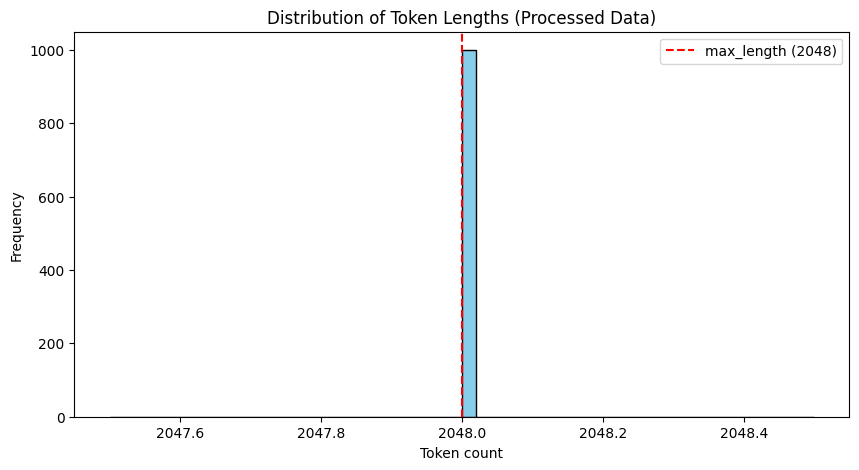

In [4]:
import matplotlib.pyplot as plt
import numpy as np


# Датасет уже прошел токенизацию, поэтому мы просто извлекаем длины готовых последовательностей
# Берем первые 1000 записей (или меньше, если датасет короче), чтобы не перегружать память
sample_size = min(1000, len(dataset))
lengths = [len(dataset[i]["input_ids"]) for i in range(sample_size)]

print(f"Медиана:         {np.median(lengths):.0f} токенов")
print(f"95-й перцентиль: {np.percentile(lengths, 95):.0f} токенов")
print(f"99-й перцентиль: {np.percentile(lengths, 99):.0f} токенов")
print(f"Максимум:        {max(lengths)} токенов")

max_len = cfg.data.get("max_length", 2048)

# Так как пайплайн уже отработал, если применялся LengthFilterTransform или SequencePackingTransform,
# то количество обрезанных примеров здесь должно быть равно 0.
# Это отличный sanity check того, что трансформации работают корректно!
cut_off_count = sum(1 for l in lengths if l > max_len) #noqa E741
print(f"Обрезается при max_length={max_len}: {cut_off_count} примеров ({cut_off_count/len(lengths)*100:.1f}%)")

plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Token Lengths (Processed Data)")
plt.xlabel("Token count")
plt.ylabel("Frequency")
plt.axvline(max_len, color='red', linestyle='dashed', linewidth=1.5, label=f'max_length ({max_len})')
plt.legend()
plt.show()

# Artifact & Noise Identification

In [5]:
import re

import pandas as pd


# Декодируем токены обратно в текст для анализа мусора
sample_size = min(1000, len(dataset))
sample_texts = [
    tokenizer.decode(dataset[i]["input_ids"], skip_special_tokens=True)
    for i in range(sample_size)
]

# Паттерны для поиска грязи
noise_patterns = {
    "extra_whitespace": r"\s{3,}",
    "html_tags": r"<[^>]+>",
    "non_printable": r"[^\x20-\x7E\u0400-\u04FF\n]",
    "urls": r"http[s]?://\S+"
}

def analyze_noise(text_list):
    stats = {}
    if not text_list:
        return dict.fromkeys(noise_patterns, 0.0)
    for name, pattern in noise_patterns.items():
        count = sum(1 for text in text_list if re.search(pattern, text))
        stats[name] = count / len(text_list)
    return stats

noise_report = analyze_noise(sample_texts)

df_noise = pd.DataFrame.from_dict(noise_report, orient='index', columns=['percentage'])

# Для наглядности отформатируем вывод в реальные проценты
df_noise['percentage'] = df_noise['percentage'].apply(lambda x: f"{x * 100:.2f}%")

print("--- Noise Artifacts Report (PROCESSED DATA) ---")
print(df_noise)

--- Noise Artifacts Report (PROCESSED DATA) ---
                 percentage
extra_whitespace      0.00%
html_tags             0.00%
non_printable       100.00%
urls                  0.00%
